In [1]:
# 01 Mask Validation
# Goal: compare TIFF alpha mask and ROI GML footprint mask


In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import rasterize
from rasterio.transform import rowcol
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon


In [5]:
image_path = Path(r"/Users/rgcappl037/Desktop/CHMv2/IMG_PHR1A_PMS_202508271555298_ORT_b24bf281-b6fd-48dc-c86f-f97e23fc09aa_R1C1.TIF")
roi_gml_path = Path(r"/Users/rgcappl037/Downloads/1bd5c88d-ff3f-4373-ac02-821d85d97cf5/IMG_PHR1A_PMS_001/MASKS/ROI_PHR1A_PMS_202508271555298_ORT_b24bf281-b6fd-48dc-c86f-f97e23fc09aa_MSK.GML")

print("Image exists:", image_path.exists())
print("ROI GML exists:", roi_gml_path.exists())
print("Image path:", image_path)
print("ROI path:", roi_gml_path)


Image exists: True
ROI GML exists: True
Image path: /Users/rgcappl037/Desktop/CHMv2/IMG_PHR1A_PMS_202508271555298_ORT_b24bf281-b6fd-48dc-c86f-f97e23fc09aa_R1C1.TIF
ROI path: /Users/rgcappl037/Downloads/1bd5c88d-ff3f-4373-ac02-821d85d97cf5/IMG_PHR1A_PMS_001/MASKS/ROI_PHR1A_PMS_202508271555298_ORT_b24bf281-b6fd-48dc-c86f-f97e23fc09aa_MSK.GML


In [7]:
with rasterio.open(image_path) as src:
    print("Driver:", src.driver)
    print("Width x Height:", src.width, "x", src.height)
    print("Band count:", src.count)
    print("Dtypes:", src.dtypes)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)
    print("Nodata:", src.nodata)
    print("Color interpretation:", src.colorinterp)


Driver: GTiff
Width x Height: 2632 x 2796
Band count: 4
Dtypes: ('uint8', 'uint8', 'uint8', 'uint8')
CRS: EPSG:32618
Resolution: (0.5, 0.5)
Bounds: BoundingBox(left=320966.0, bottom=4315754.0, right=322282.0, top=4317152.0)
Nodata: None
Color interpretation: (<ColorInterp.red: 3>, <ColorInterp.green: 4>, <ColorInterp.blue: 5>, <ColorInterp.undefined: 0>)


In [9]:
with rasterio.open(image_path) as src:
    rgb = src.read([1, 2, 3])
    alpha = src.read(4)
    transform = src.transform
    bounds = src.bounds
    height = src.height
    width = src.width

rgb_hwc = np.moveaxis(rgb, 0, -1)
alpha_mask = alpha > 0

print("Alpha min:", alpha.min())
print("Alpha max:", alpha.max())
print("Alpha valid pixels:", int(alpha_mask.sum()))
print("Alpha invalid pixels:", int((~alpha_mask).sum()))
print("Alpha unique sample:", np.unique(alpha)[:20])


Alpha min: 0
Alpha max: 255
Alpha valid pixels: 4530224
Alpha invalid pixels: 2828848
Alpha unique sample: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


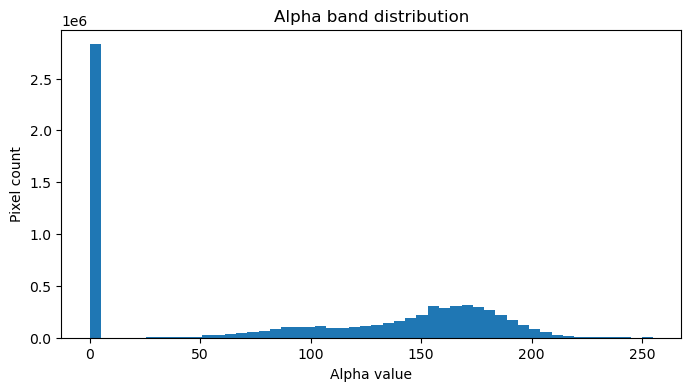

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(alpha.ravel(), bins=50)
plt.xlabel("Alpha value")
plt.ylabel("Pixel count")
plt.title("Alpha band distribution")
plt.show()


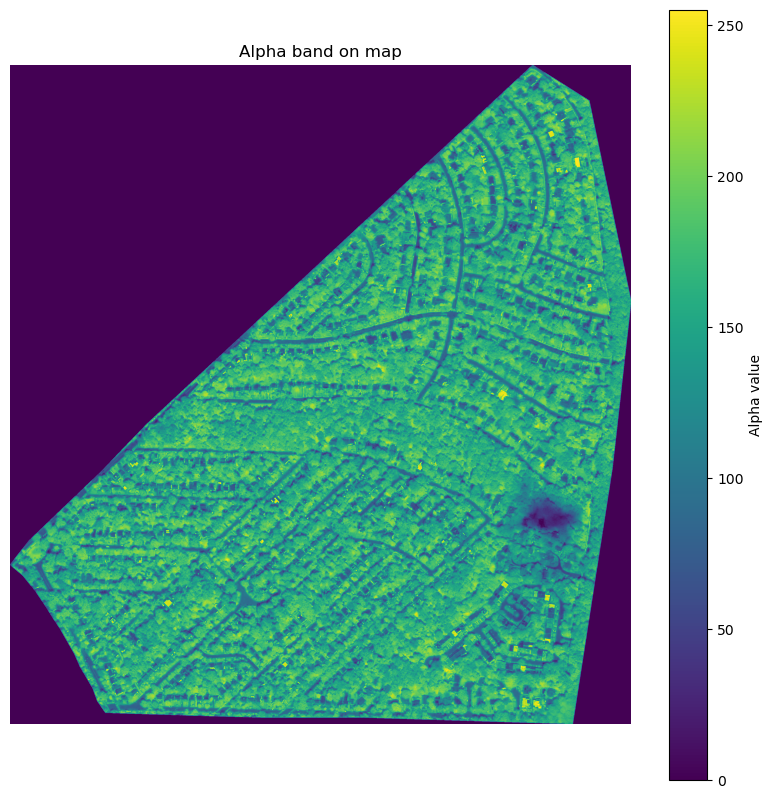

In [13]:
plt.figure(figsize=(10, 10))
plt.imshow(alpha, cmap="viridis")
plt.colorbar(label="Alpha value")
plt.title("Alpha band on map")
plt.axis("off")
plt.show()


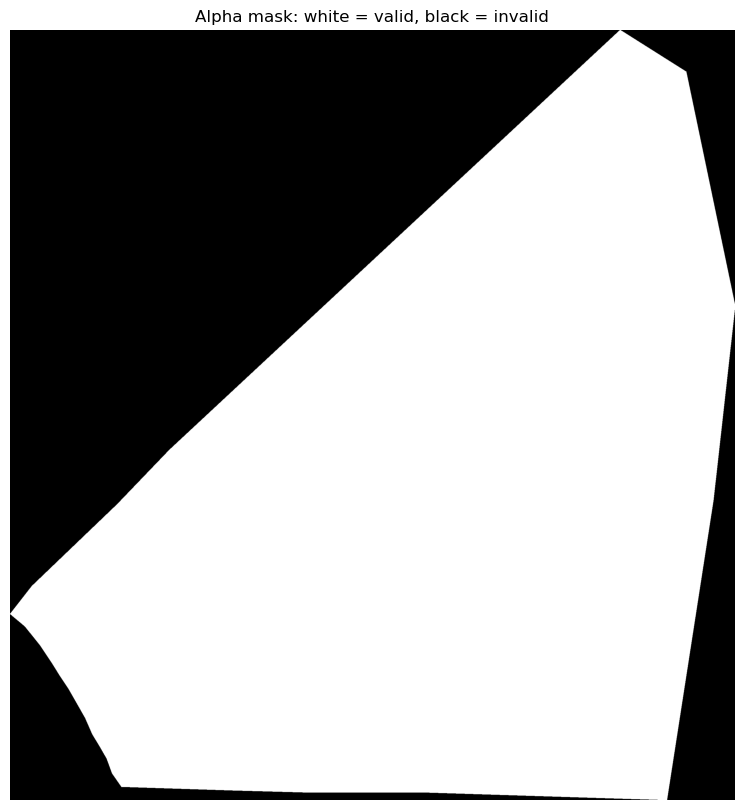

In [15]:
plt.figure(figsize=(10, 10))
plt.imshow(alpha_mask, cmap="gray")
plt.title("Alpha mask: white = valid, black = invalid")
plt.axis("off")
plt.show()


In [17]:
tree = ET.parse(roi_gml_path)
root = tree.getroot()

ns = {
    "gml": "http://www.opengis.net/gml",
    "hma": "http://earth.esa.int/hma"
}

poslist = root.find(".//gml:posList", ns)
coords = list(map(float, poslist.text.strip().split()))
points = [(coords[i], coords[i + 1]) for i in range(0, len(coords), 2)]

roi_polygon = Polygon(points)

print("ROI polygon loaded")
print("Number of vertices:", len(points))
print("Polygon bounds:", roi_polygon.bounds)
print("First 5 points:", points[:5])


ROI polygon loaded
Number of vertices: 21
Polygon bounds: (320965.75, 4315754.25, 322281.75, 4317152.25)
First 5 points: [(322072.75, 4317152.25), (321257.75, 4316393.25), (321154.25, 4316285.25), (321004.75, 4316142.75), (320965.75, 4316092.75)]


In [19]:
roi_mask = rasterize(
    [(roi_polygon, 1)],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="uint8"
).astype(bool)

print("ROI valid pixels:", int(roi_mask.sum()))
print("ROI invalid pixels:", int((~roi_mask).sum()))


ROI valid pixels: 4531987
ROI invalid pixels: 2827085


In [21]:
same = alpha_mask == roi_mask
only_alpha_valid = alpha_mask & (~roi_mask)
only_roi_valid = roi_mask & (~alpha_mask)

print("Pixels where masks agree:", int(same.sum()))
print("Percent agreement:", round(100 * same.mean(), 4), "%")
print("Valid in alpha only:", int(only_alpha_valid.sum()))
print("Valid in ROI only:", int(only_roi_valid.sum()))


Pixels where masks agree: 7354101
Percent agreement: 99.9325 %
Valid in alpha only: 1604
Valid in ROI only: 3367


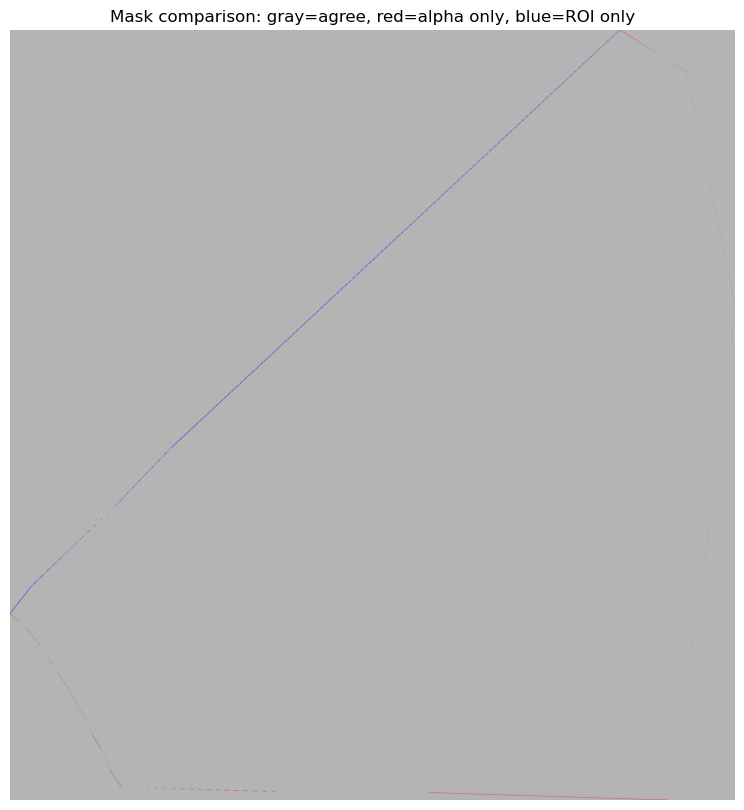

In [23]:
diff = np.zeros((height, width, 3), dtype=np.uint8)
diff[same] = [180, 180, 180]
diff[only_alpha_valid] = [255, 0, 0]
diff[only_roi_valid] = [0, 0, 255]

plt.figure(figsize=(10, 10))
plt.imshow(diff)
plt.title("Mask comparison: gray=agree, red=alpha only, blue=ROI only")
plt.axis("off")
plt.show()


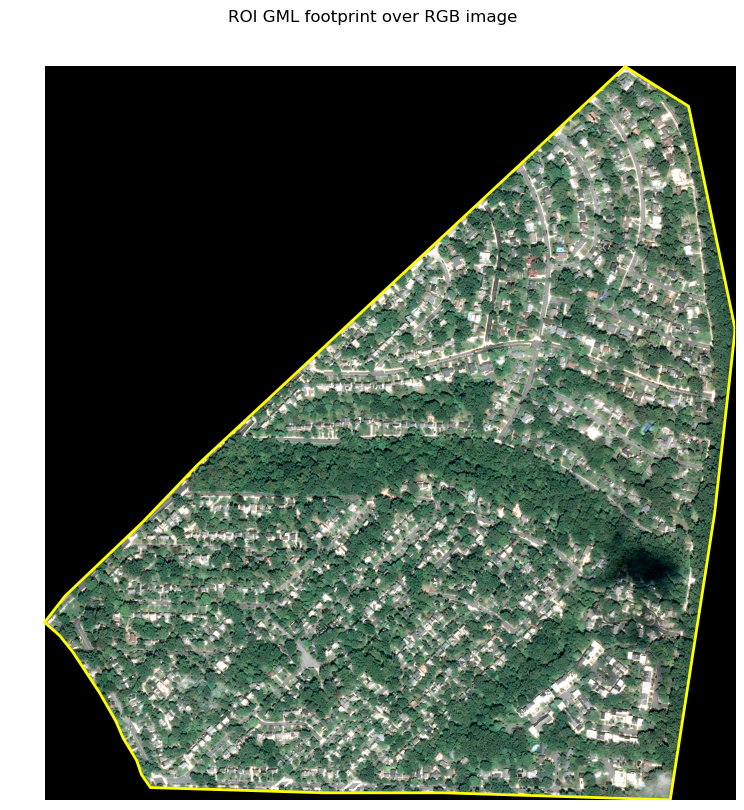

In [25]:
rgb_disp = rgb_hwc.astype(np.float32).copy()
for b in range(3):
    p2, p98 = np.percentile(rgb_disp[..., b], (2, 98))
    if p98 > p2:
        rgb_disp[..., b] = np.clip((rgb_disp[..., b] - p2) / (p98 - p2), 0, 1)

rows = []
cols = []
for x, y in points:
    r, c = rowcol(transform, x, y)
    rows.append(r)
    cols.append(c)

plt.figure(figsize=(10, 10))
plt.imshow(rgb_disp)
plt.plot(cols, rows, color="yellow", linewidth=2)
plt.title("ROI GML footprint over RGB image")
plt.axis("off")
plt.show()


In [27]:
print("Conclusion:")
print("- The TIFF alpha band and ROI GML footprint are highly consistent.")
print("- This supports using alpha-based masking for downstream preprocessing.")
print("- The ROI GML remains a strong metadata-based cross-check.")


Conclusion:
- The TIFF alpha band and ROI GML footprint are highly consistent.
- This supports using alpha-based masking for downstream preprocessing.
- The ROI GML remains a strong metadata-based cross-check.


SyntaxError: invalid decimal literal (392139563.py, line 1)